# Principle Component Analysis and Plotting for Polar Tests

1. ### Doing regular PCA on spectral cube: ###
    - **Results**: the PCA is degenerate: cannot distinguish time scales
2. ### Doing band-pass PCA on spectral cube: ###
    - **Results**:

In [1]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pickle
from scipy.signal import savgol_filter

from matplotlib.gridspec import GridSpec
from astropy.timeseries import LombScargle
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt

import pandas as pd
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d

# make plotPaths in top directory
topDir = os.path.dirname(os.getcwd())
plotDir = os.path.join(topDir, 'paperPlots')
if not os.path.exists(plotDir):
    os.makedirs(plotDir)
print("Saving plots to ", plotDir)

# test = True
test = False

/Users/nguyendat/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/nguyendat/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Saving plots to  /Users/nguyendat/Documents/GitHub/polarVortexJwst/paperPlots


### Helper functions, initializations

In [2]:
### Functions to read in spectra time series data ###
default_specConfigName = '1200k_clouds=20'
print('\n######; Imported function to read in spectra time series data')
def read_spec_codecs(photrunName, specConfigName=default_specConfigName):

    ### 1. Read in photometry results
    phot = readPhotometry(os.path.join(photometryh5dir, photrunName))

    ### 2. Read in spectra time series data + codec data
    runname = f'timeseries_{photrunName[:-3]}_{specConfigName}'
    dirPath = os.path.join(os.getcwd(), runname)

    # Search for files matching the pattern 'i=*.h5' in the directory
    spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
    codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

    # Initialize the specs dictionary
    specs = {}
    codecs = {}

    # Iterate through each inclination file and load spectra
    for index, file in enumerate(spectra_files):
        inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename

        specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
        codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

    ### 3. Load codec configuration
    configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
    codec_loaded = CodecSystem()
    codec_loaded.import_mapping(configPath, validate_files=False)
    
    return phot, specs, codecs, codec_loaded

### Load the full picaso result summary

# Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
# specFolderName = 'bd_grid_20251108_162457_all5condensates'
# specFolderName = 'bd_grid_20251202_simple3clouds'
specFolderName = 'bd_grid_noCH4_20251209_153457'

specpath = os.path.join(dir, specFolderName)
specSummary = pickle.load(open(os.path.join(specpath, 'results_summary.pkl'), 'rb'))

modelID_list = [picasomodelfile['model_id'] for picasomodelfile in specSummary]
print(f"\nFound {len(modelID_list)} model IDs in the summary:")
print(modelID_list)
print("\nSample params file: ")
print(specSummary[0]['params'])

# fsed_list
fsed_list = []
# Loop through all codec_id and get fsed
for picasomodelfile in specSummary:
    fsed = picasomodelfile['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list.append((modelid, fsed))

# calculate binned flux at given wavelength range (take a spectra timeseries array per inclination)
print("\n#####; Imported function for calculating binned flux")
def calculate_wavebin_flux(specs_inclin, wmin, wmax):
        flux_ts = []
        for keys in specs_inclin:
            frame_i, wave_i, flux_i = specs_inclin[keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_ts.append(median_flux)
        return flux_ts


######; Imported function to read in spectra time series data

Found 20 model IDs in the summary:
['bd_1200_10000_1.0E+07_1.00_cloudy', 'bd_1200_10000_1.0E+07_1.01_cloudy', 'bd_1200_10000_1.0E+07_1.02_cloudy', 'bd_1200_10000_1.0E+07_1.03_cloudy', 'bd_1200_10000_1.0E+07_1.04_cloudy', 'bd_1200_10000_1.0E+07_1.05_cloudy', 'bd_1200_10000_1.0E+07_1.06_cloudy', 'bd_1200_10000_1.0E+07_1.07_cloudy', 'bd_1200_10000_1.0E+07_1.08_cloudy', 'bd_1200_10000_1.0E+07_1.09_cloudy', 'bd_1200_10000_1.0E+07_1.10_cloudy', 'bd_1200_10000_1.0E+07_1.11_cloudy', 'bd_1200_10000_1.0E+07_1.12_cloudy', 'bd_1200_10000_1.0E+07_1.13_cloudy', 'bd_1200_10000_1.0E+07_1.14_cloudy', 'bd_1200_10000_1.0E+07_1.15_cloudy', 'bd_1200_10000_1.0E+07_1.16_cloudy', 'bd_1200_10000_1.0E+07_1.17_cloudy', 'bd_1200_10000_1.0E+07_1.18_cloudy', 'bd_1200_10000_1.0E+07_1.19_cloudy']

Sample params file: 
{'Teff': 1200, 'C_to_O': 0.0, 'mh': 1.0, 'gravity': 10000, 'kzz': 10000000.0, 'phase': 0, 'wave_range': [1, 6], 'eq': False, 'excluded_mol

### Importing simulated timeseries of 60-hour baselines case.

In [3]:

### Read the photometry file
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### Test-dataset: 

# 60 hours baseline, static pole: Test Static (ts)
photrunName_ts = 'test_polar_v0_static.h5'
phot_ts, specs_ts, codecs_ts, codec_loaded_ts = read_spec_codecs(photrunName_ts) 
time_ts = phot_ts['0']['time_array'] # load the time indices 

# 60 hours baseline, dynamic pole: Test Dynamic (td)
photrunName_td = 'test_polar_v0_dynamic.h5'
phot_td, specs_td, codecs_td, codec_loaded_td = read_spec_codecs(photrunName_td) 
time_td = phot_td['0']['time_array'] # load the time indices 


Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_dynamic_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20


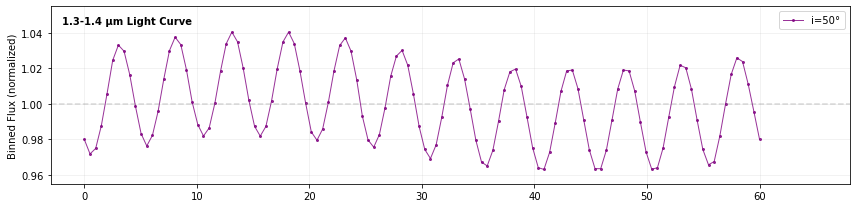

In [4]:
### Plot 1.3-1.4um light curve

# save = True
save = False 
normalize = True
codename = photrunName_ts[:-3] + '_' + default_specConfigName

fig, axs = plt.subplots(1, 1, figsize=(12, 3))
if test: fig.suptitle(codename, fontsize=6)

wavebin = [ (1.3, 1.4)]

inc_array = ['50']
markerstyles = ['o', '^', 's']
linestyles = ['-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = ['purple', 'magenta', 'orange']

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
        
        # Plot normalized light curve
        # normalize flux mean to 1
        if normalize:
            flux_ts = np.array(flux_ts)
            flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1

        ax.plot(time_ts, flux_ts, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[j],
                linewidth=1, markersize=2+0.5*j,
                label=f'i={inclin}°')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(-3, 68)
    if normalize: ax.set_ylim(0.955, 1.055)
    ax.legend(),
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(-2, 1.045, f'{wmin}-{wmax} μm Light Curve', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


In [5]:
### Convert to dataframe for PCA

# For static 60-hour dataset
specs_ts_df = {}
for inc in specs_ts.keys():
    wave = specs_ts[inc][0]['wave'] # Pick any inclination key to build the DataFrame
    # (wave is the same across all time indices)
    flux = np.array([specs_ts[inc][t]['flux'] for t in sorted(specs_ts[inc].keys())])
    df = pd.DataFrame(np.vstack([wave[np.newaxis, :], flux]))
    df.index = ['wave'] + sorted(specs_ts[inc].keys())
    specs_ts_df[inc] = df

# For dynamic 60-hour dataset
specs_td_df = {}
for inc in specs_td.keys():
    wave = specs_td[inc][0]['wave'] # Pick any inclination key to build the DataFrame
    # (wave is the same across all time indices)
    flux = np.array([specs_td[inc][t]['flux'] for t in sorted(specs_td[inc].keys())])
    df = pd.DataFrame(np.vstack([wave[np.newaxis, :], flux]))
    df.index = ['wave'] + sorted(specs_td[inc].keys())
    specs_td_df[inc] = df

specs_ts_df['0'].head(25)

,0,1,2,3,4,5,6,7,8,9,...,1245,1246,1247,1248,1249,1250,1251,1252,1253,1254
wave,9.995744e-01,1.001003e+00,1.002434e+00,1.003867e+00,1.005303e+00,1.006740e+00,1.008179e+00,1.009620e+00,1.011064e+00,1.012509e+00,...,5.918873e+00,5.927334e+00,5.935808e+00,5.944294e+00,5.952792e+00,5.961302e+00,5.969824e+00,5.978358e+00,5.986905e+00,5.995464e+00
0,3.627955e-09,3.661724e-09,3.706306e-09,3.747024e-09,3.795999e-09,3.840329e-09,3.889402e-09,3.936226e-09,3.980420e-09,4.029395e-09,...,3.596025e-07,4.060373e-07,2.624574e-07,3.264506e-07,3.050889e-07,4.605654e-07,3.268523e-07,4.287584e-07,3.533322e-07,4.038917e-07
1,3.626547e-09,3.660304e-09,3.704869e-09,3.745574e-09,3.794531e-09,3.838845e-09,3.887900e-09,3.934707e-09,3.978886e-09,4.027843e-09,...,3.595944e-07,4.060255e-07,2.624548e-07,3.264454e-07,3.050842e-07,4.605477e-07,3.268455e-07,4.287439e-07,3.533224e-07,4.038776e-07
2,3.630077e-09,3.663865e-09,3.708471e-09,3.749210e-09,3.798213e-09,3.842566e-09,3.891666e-09,3.938515e-09,3.982733e-09,4.031734e-09,...,3.596150e-07,4.060552e-07,2.624614e-07,3.264586e-07,3.050961e-07,4.605925e-07,3.268628e-07,4.287804e-07,3.533471e-07,4.039131e-07
3,3.635095e-09,3.668926e-09,3.713589e-09,3.754379e-09,3.803446e-09,3.847854e-09,3.897018e-09,3.943927e-09,3.988200e-09,4.037264e-09,...,3.596441e-07,4.060973e-07,2.624708e-07,3.264773e-07,3.051129e-07,4.606558e-07,3.268872e-07,4.288319e-07,3.533819e-07,4.039633e-07
4,3.638564e-09,3.672426e-09,3.717128e-09,3.757952e-09,3.807064e-09,3.851510e-09,3.900718e-09,3.947668e-09,3.991980e-09,4.041087e-09,...,3.596638e-07,4.061258e-07,2.624772e-07,3.264900e-07,3.051242e-07,4.606987e-07,3.269037e-07,4.288668e-07,3.534055e-07,4.039974e-07
5,3.664422e-09,3.698510e-09,3.743507e-09,3.784590e-09,3.834035e-09,3.878766e-09,3.928303e-09,3.975561e-09,4.020158e-09,4.069588e-09,...,3.598153e-07,4.063446e-07,2.625262e-07,3.265874e-07,3.052115e-07,4.610281e-07,3.270307e-07,4.291347e-07,3.535869e-07,4.042585e-07
6,3.668568e-09,3.702693e-09,3.747737e-09,3.788860e-09,3.838359e-09,3.883136e-09,3.932724e-09,3.980032e-09,4.024674e-09,4.074156e-09,...,3.598381e-07,4.063775e-07,2.625335e-07,3.266020e-07,3.052245e-07,4.610778e-07,3.270498e-07,4.291751e-07,3.536142e-07,4.042980e-07
7,3.668593e-09,3.702718e-09,3.747762e-09,3.788886e-09,3.838385e-09,3.883162e-09,3.932751e-09,3.980059e-09,4.024701e-09,4.074183e-09,...,3.598382e-07,4.063777e-07,2.625335e-07,3.266020e-07,3.052246e-07,4.610781e-07,3.270498e-07,4.291752e-07,3.536143e-07,4.042982e-07
8,3.669353e-09,3.703484e-09,3.748537e-09,3.789668e-09,3.839177e-09,3.883962e-09,3.933560e-09,3.980876e-09,4.025527e-09,4.075019e-09,...,3.598410e-07,4.063818e-07,2.625344e-07,3.266038e-07,3.052262e-07,4.610846e-07,3.270522e-07,4.291805e-07,3.536178e-07,4.043034e-07


### Plot spectral cube for `static` case for inclination 90

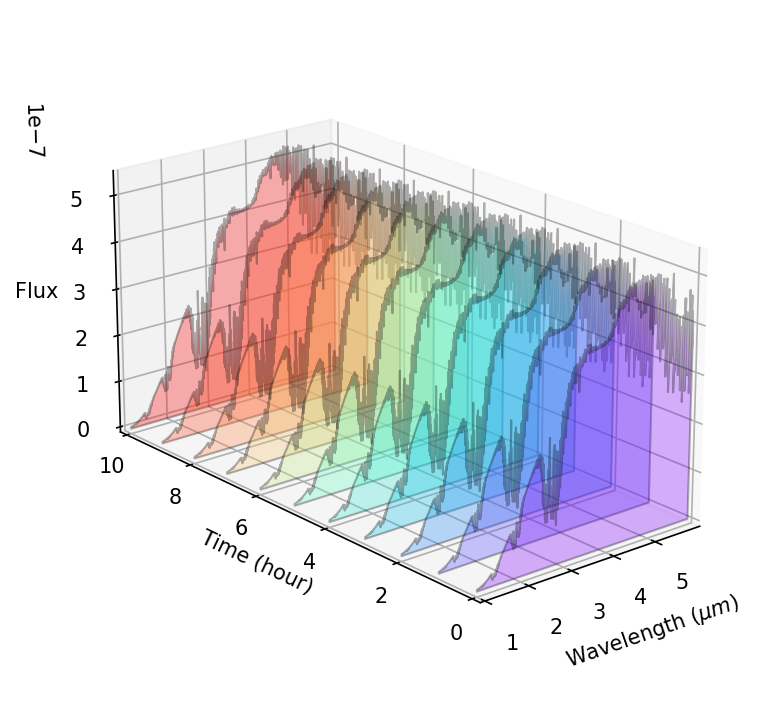

In [6]:
from matplotlib.collections import PolyCollection
from matplotlib import cm
viridis = cm.get_cmap('rainbow_r', 12)

# normalize_to_reference = True  # set to False to plot raw fluxes
normalize_to_reference = False  # set to False to plot raw fluxes

def polygon_under_graph(x, y):
    """
    Construct the vertex list which defines the polygon filling the space under
    the (x, y) line graph. This assumes x is in ascending order.
    """
    return [(x[0], 0.), *zip(x, y), (x[-1], 0.)]

# Pick an inclination
incl_key = '90'

# Extract wave (first row) and flux rows (all remaining rows)
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)

if normalize_to_reference:
    flux_raw = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
    reference = flux_raw[60]  # or use np.mean(flux_raw, axis=0) for mean-normalized
    flux_df = (flux_raw - reference)/reference  # now 0 = no change, ±0.1 = ±10%

else: flux_df = specs_ts_df[incl_key] .iloc[1:].values.astype(float)

# Control which time steps to plot and spacing
n_steps = 11          # number of time steps to plot
skip = 1             # skip every N time steps
time_indices = list(range(0, n_steps * skip, skip))  # e.g. [0, 6, 12, 18, ...]

# Build polygons from the selected time steps
verts = [polygon_under_graph(wave, flux_df[t]) for t in time_indices]
labels = [t/skip for t in time_indices]  # for y-axis positioning

facecolors = viridis(np.linspace(0, 1, len(verts)))
poly = PolyCollection(verts, facecolors=facecolors, edgecolors=("black"), alpha=.3)

ax = plt.figure(figsize=(15,6), dpi=150).add_subplot(projection='3d')
ax.view_init(elev=20, azim=50)  # adjust azim to rotate left-right
ax.set_box_aspect([1, 2, 1])  # [wavelength, time step, flux]

ax.add_collection3d(poly, zs=np.flip(labels), zdir='y')

ax.set(
    xlim=(wave.max(), wave.min()),
    ylim=(max(labels), min(labels)),
    zlim=(0, flux_df.max()),
    xlabel=r'Wavelength $(\mu m)$',
    ylabel='Time (hour)',
    zlabel='Flux'
)
plt.show()

In [7]:
# find the time-median spectrum across the time series
# Pick an inclination
incl_key = '50'

# do a median on data frame across time steps
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum = np.median(flux, axis=0)

# plot the max and min spectrum at t argmax and t argmin
max_index = np.argmax(np.sum(flux, axis=1))
min_index = np.argmin(np.sum(flux, axis=1))

### Plot interactive bokeh plot
from bokeh.plotting import figure, show, output_notebook
output_notebook()

p = figure(x_axis_label='Wave',
           y_axis_label='Flux',
           y_axis_type='linear',
           width = 800, height = 400)

p.line(wave, median_spectrum, color='blue', legend_label='Median spectrum')
p.line(wave, flux[max_index], color='red', legend_label=f'Max spectrum at t={max_index/2} hr')
p.line(wave, flux[min_index], color='green', legend_label=f'Min spectrum at t={min_index/2} hr')

p.legend.location = "top_left"

show(p)


Loading BokehJS ...

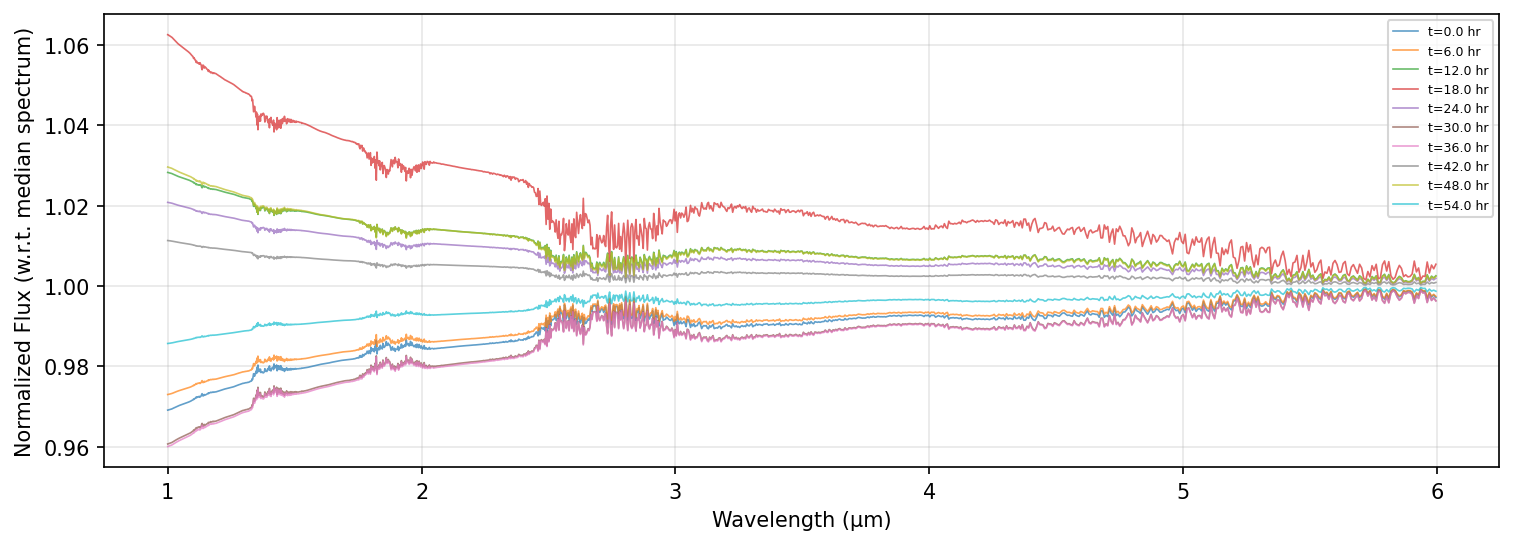

In [16]:
### divide flux by the median spectrum
flux = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum = np.median(flux, axis=0)
flux_normalized = flux / median_spectrum[np.newaxis, :]

### plot some spectra from the normalized flux matrix
plt.figure(figsize=(12,4), dpi=150)
indexs = np.arange(0, flux_normalized.shape[0], int(flux_normalized.shape[0]/10))
for idx in indexs:
    plt.plot(wave, flux_normalized[idx], alpha=0.7, lw=0.8, label=f't={idx/2} hr')
plt.xlabel('Wavelength (μm)')
plt.ylabel('Normalized Flux (w.r.t. median spectrum)')
plt.legend(fontsize=6)
plt.grid(True, alpha=0.3)

## 1. Doing regular PCA on spectral cube

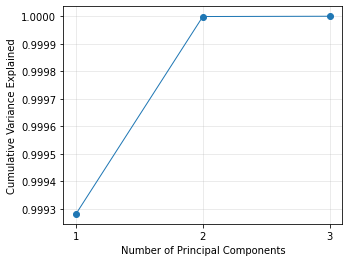

In [20]:
### Doing standard scaling (mean=0, std=1) on each wavelength bin
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
flux_scaled = scaler.fit_transform(flux_normalized.T).T  # transpose to scale each wavelength bin

### Doing PCA on the normalized flux matrix and plot cummulative variance explained
pca = PCA(n_components=3)
pca.fit(flux_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(5,4))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker='o', lw=1)
plt.xticks(np.arange(1, len(cumulative_variance)+1))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
# make y axis E formatted
# plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

Relative variance in principal components: [9.99951437e-01 4.85546780e-05 8.73425144e-09]


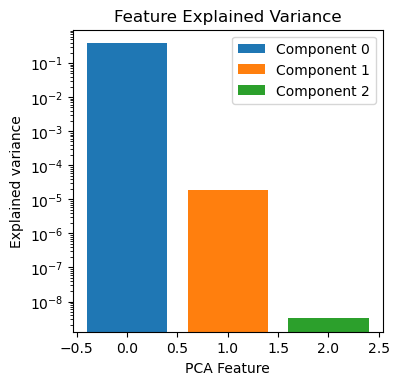

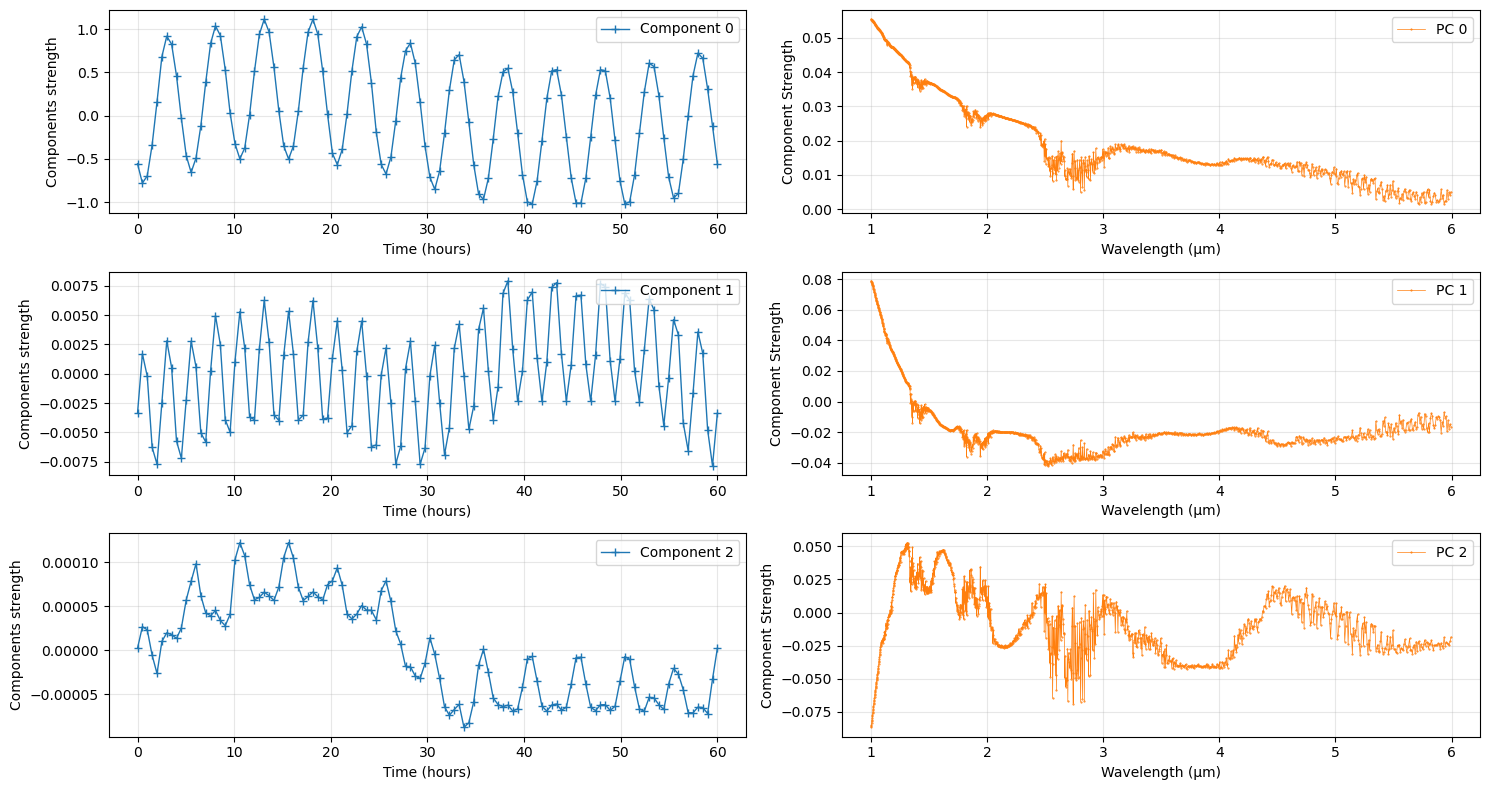

In [21]:
### Redo PCA for 3 components and plot all the component in flux and wavelength space
# pca = PCA(n_components=0.9999)
pca = PCA(n_components=3)
pca.fit(flux_normalized)
X_pca = pca.transform(flux_normalized)

print("Relative variance in principal components:", pca.explained_variance_ratio_)
# Bar plot of explained_variance
plt.figure(figsize=(4,4),dpi=100)
for i, variance in enumerate(pca.explained_variance_):
    plt.bar(i, variance, label='Component %i'%i)
plt.xlabel('PCA Feature'), plt.ylabel('Explained variance'), plt.legend(loc='upper right')
plt.title('Feature Explained Variance'),
plt.yscale('log')
plt.show()
plt.close()

fig, axs = plt.subplots(3,2,figsize=(15, 8),dpi=100)
for i, comp in enumerate(np.transpose(X_pca)):
    # print(comp)
    axs[i,0].plot(time_ts, comp, ls='-', marker='+', ms=6, lw=1, label='Component %i'%i)
    axs[i,0].set_xlabel('Time (hours)')
    axs[i,0].set_ylabel('Components strength')
    axs[i,0].legend(loc='upper right')
    axs[i,0].grid(True, alpha=0.3)

    axs[i,1].plot(wave, pca.components_[i], c='tab:orange', 
                ls='-', marker='o', ms=0.5, lw=0.5, label='PC %i'%i)
    axs[i,1].set_xlabel('Wavelength (μm)')
    axs[i,1].set_ylabel('Component Strength')
    axs[i,1].legend(loc='upper right')
    axs[i,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Doing bandpass PCA on spectral cube of i=20, 50

### 2A. Bandpass periodogram PCA for i=50

In [ ]:
### Do periodogram analysis for static 60-hour dataset at i=50° 
periods = np.linspace(0.5, 100, 2000)      # hours
freqs   = 1.0 / periods                    # cycles / hour

n_frames, n_wave = flux.shape
powers = np.zeros((n_wave, len(periods)))  # (1255, 2000)

for i in range(n_wave):
    lc = flux_normalized[:, i] - 1.0       # subtract baseline
    ls = LombScargle(time_ts, lc)
    powers[i, :] = ls.power(freqs)

# regular PCA on the periodogram powers
pca_pg = PCA(n_components=5)
pg_scores = pca_pg.fit_transform(powers)     # (1255, 5)
# ─── BANDPASS FILTER + PCA (fallback if periodogram PCA is degenerate) ────
dt   = time_ts[1] - time_ts[0]              # 0.5 hr
fs   = 1.0 / dt                             # 2 cycles/hr (sampling freq)
nyq  = fs / 2.0                             # 1 cycle/hr

def bandpass(data_1d, lo_period, hi_period, fs, nyq, order=2):
    """Butter bandpass on a single light curve. lo/hi are in hours (period)."""
    lo_freq = 1.0 / hi_period   # lower freq edge
    hi_freq = 1.0 / lo_period   # upper freq edge
    b, a = butter(order, [lo_freq / nyq, hi_freq / nyq], btype='band')
    return filtfilt(b, a, data_1d)

# 5-hr mode: centred on 5 hr
# 60-hr mode: centred on 60 hr, upper = Nyquist-ish
filtered_5h  = np.zeros_like(flux_normalized)            # (120, 1255)
filtered_60h = np.zeros_like(flux_normalized)            # (120, 1255)

band1_low, band1_high = 2, 20       # hours
band2_low, band2_high = 40, 80     # hours

for i in range(n_wave):
    lc = flux_normalized[:, i] - 1.0
    filtered_5h[:, i]  = bandpass(lc,  band1_low,  band1_high,  fs, nyq)
    filtered_60h[:, i] = bandpass(lc, band2_low, band2_high,  fs, nyq)

# PCA on each filtered cube  (rows = frames, cols = wave → transpose for "spectral PCA")
# We want to find the *spectral shape* of each mode, so we PCA across wavelength.
# Transpose: (1255 wave × 120 frames) so each row is a wavelength's filtered LC.
pca_5h  = PCA(n_components=3)
scores_5h  = pca_5h.fit_transform(filtered_5h.T)   # (1255, 3)

pca_60h = PCA(n_components=3)
scores_60h = pca_60h.fit_transform(filtered_60h.T) # (1255, 3)

ValueError: x and y must have same first dimension, but have shapes (120,) and (1255,)

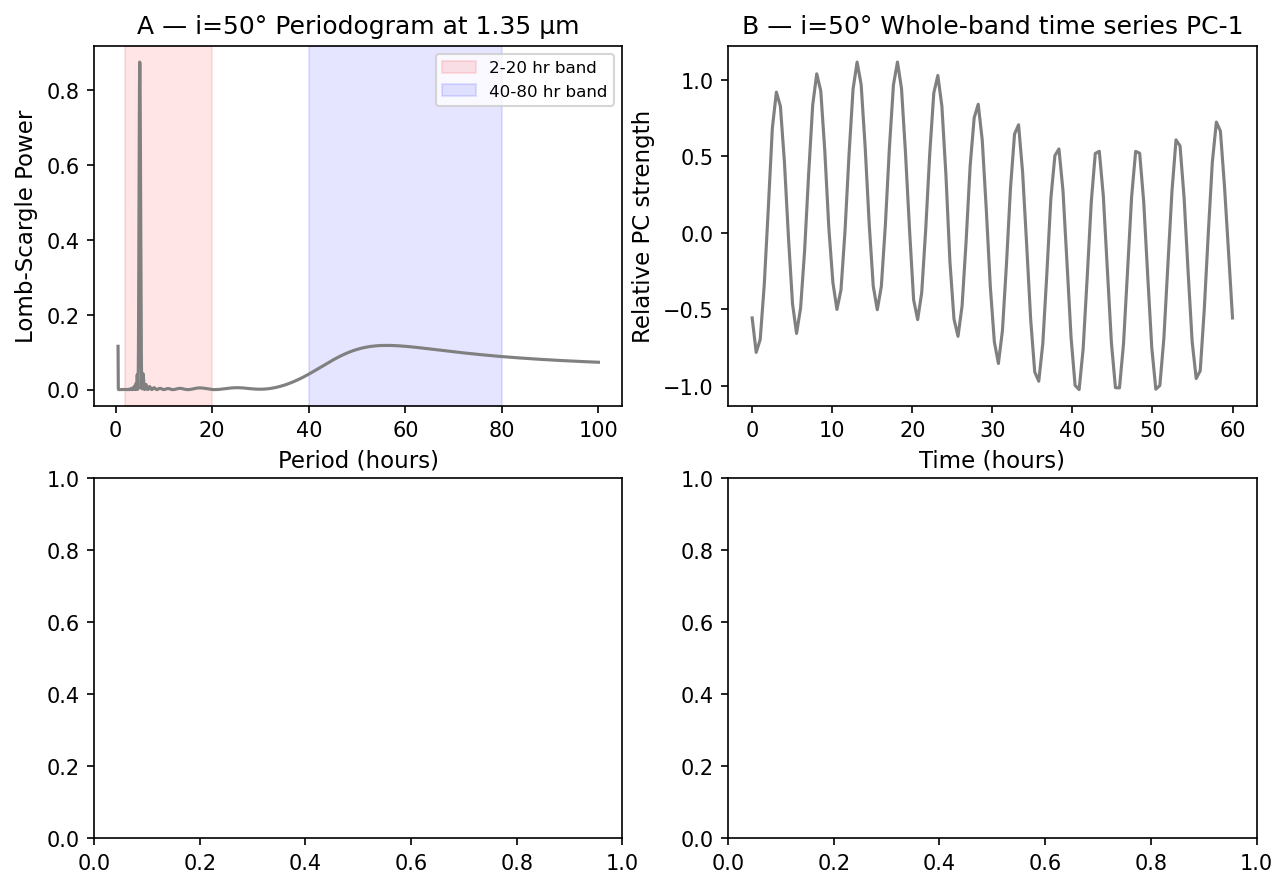

In [ ]:
### Plot periodogram analysis for static 60-hour dataset at i=50°
# save = True 
save = False

fig, axs = plt.subplots(2, 2 , figsize=(10, 7), dpi=150)

# --- Panel A: Periodograms ---
ax = axs[0, 0]
# plot periodogram of 1.35um light curve
idx_1 = np.argmin(np.abs(wave - 1.35))
lc_1 = flux_normalized[:, idx_1] - 1.0
ls_1 = LombScargle(time_ts, lc_1)
power_1 = ls_1.power(freqs)
ax.plot(periods, power_1, color="gray", lw=1.5)
ax.set_xlabel("Period (hours)", fontsize=11)
ax.set_ylabel("Lomb-Scargle Power", fontsize=11)
ax.set_title("A — i=50° Periodogram at 1.35 µm", fontsize=12)

# draw box around 3-8 hr and 20-100 hr regions
ax.axvspan(band1_low, band1_high, color='r', alpha=0.1, label=f"{band1_low}-{band1_high} hr band")
ax.axvspan(band2_low, band2_high, color='b', alpha=0.1, label=f"{band2_low}-{band2_high} hr band")
ax.legend(fontsize=8)

# --- Panel B: First PCA component over time
ax = axs[0, 1]
pc1_time = X_pca[:, 0]
ax.plot(time_ts, pc1_time, color="gray", lw=1.5)
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Relative PC strength", fontsize=11)
ax.set_title("B — i=50° Whole-band time series PC-1", fontsize=12)

# --- Panel C: Bandpass filtered light curves over two bands
ax = axs[1, 0]

lc_5h_1 = pca_5h.transform(filtered_5h[:, idx_1])
lc_60h_1 = pca_60h.transform(filtered_60h[:, idx_1])
ax.plot(time_ts, lc_5h_1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}-{band1_high} hr band")
ax.plot(time_ts, lc_60h_1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}-{band2_high} hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux (normalized)", fontsize=11)
ax.set_title("C — i=50° Bandpass filtered light curves", fontsize=12)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()

# --- Panel D: PCA over wavelengths of bandpass filtered data ---
ax = axs[1, 1]
# use the first PCA component from each bandpass filtered data
score_60h_pc1 = scores_60h[:, 0]
score_5h_pc1 = scores_5h[:, 0]

# flip y axis of 5h score and move minimum to 0
score_5h_pc1 = 1+ score_5h_pc1 - np.min(score_5h_pc1) 
# move minimum of 60h score to 0
score_60h_pc1 = 1+ score_60h_pc1 - np.min(score_60h_pc1)

ax.plot(wave, score_5h_pc1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}–{band1_high} hr bandpass PC1")
ax.plot(wave, score_60h_pc1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}–{band2_high} hr bandpass PC1")
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("Relative PC strength", fontsize=11)
ax.set_title("D — PCs of bandpass filtered spectra", fontsize=12)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
if save:
    handle = f'PCA_i=50_bandpass_filter.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)

### 2B. Bandpass periodogram PCA for i=20

In [56]:
### Do similar periodogram analysis for dynamic 60-hour dataset at i=20°

incl_key = '20'
specs_ts_df[incl_key]  = specs_ts_df[incl_key] 
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux_i20 = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum_i20 = np.median(flux_i20, axis=0)
flux_normalized_i20 = flux_i20 / median_spectrum_i20[np.newaxis, :]

# PCA
pca_i20 = PCA(n_components=3)
pca_i20.fit(flux_normalized_i20)
X_pca_i20 = pca_i20.transform(flux_normalized_i20)

### Do periodogram analysis for static 60-hour dataset at i=20° 
periods = np.linspace(0.5, 100, 2000)      # hours
freqs   = 1.0 / periods                    # cycles / hour

n_frames, n_wave = flux_i20.shape
powers_i20 = np.zeros((n_wave, len(periods)))  # (1255, 2000)

for i in range(n_wave):
    lc = flux_normalized_i20[:, i] - 1.0       # subtract baseline
    ls = LombScargle(time_ts, lc)
    powers_i20[i, :] = ls.power(freqs)

# regular PCA on the periodogram powers
pca_pg = PCA(n_components=5)
pg_scores = pca_pg.fit_transform(powers_i20)     # (1255, 5)
# ─── BANDPASS FILTER + PCA (fallback if periodogram PCA is degenerate) ────
dt   = time_ts[1] - time_ts[0]              # 0.5 hr
fs   = 1.0 / dt                             # 2 cycles/hr (sampling freq)
nyq  = fs / 2.0                             # 1 cycle/hr

def bandpass(data_1d, lo_period, hi_period, fs, nyq, order=2):
    """Butter bandpass on a single light curve. lo/hi are in hours (period)."""
    lo_freq = 1.0 / hi_period   # lower freq edge
    hi_freq = 1.0 / lo_period   # upper freq edge
    b, a = butter(order, [lo_freq / nyq, hi_freq / nyq], btype='band')
    return filtfilt(b, a, data_1d)

# 5-hr mode: keep periods 3–8 hr  (centred on 5 hr)
# 60-hr mode: keep periods 20–100 hr  (centred on 60 hr, upper = Nyquist-ish)
filtered_5h  = np.zeros_like(flux_normalized_i20)            # (120, 1255)
filtered_60h = np.zeros_like(flux_normalized_i20)            # (120, 1255)

band1_low, band1_high = 2, 20       # hours
band2_low, band2_high = 40, 80     # hours

for i in range(n_wave):
    lc = flux_normalized_i20[:, i] - 1.0
    filtered_5h[:, i]  = bandpass(lc,  band1_low,  band1_high,  fs, nyq)
    filtered_60h[:, i] = bandpass(lc, band2_low, band2_high,  fs, nyq)

# PCA on each filtered cube  (rows = frames, cols = wave → transpose for "spectral PCA")
# We want to find the *spectral shape* of each mode, so we PCA across wavelength.
# Transpose: (1255 wave × 120 frames) so each row is a wavelength's filtered LC.
pca_5h  = PCA(n_components=3)
scores_5h  = pca_5h.fit_transform(filtered_5h.T)   # (1255, 3)

pca_60h = PCA(n_components=3)
scores_60h = pca_60h.fit_transform(filtered_60h.T) # (1255, 3)


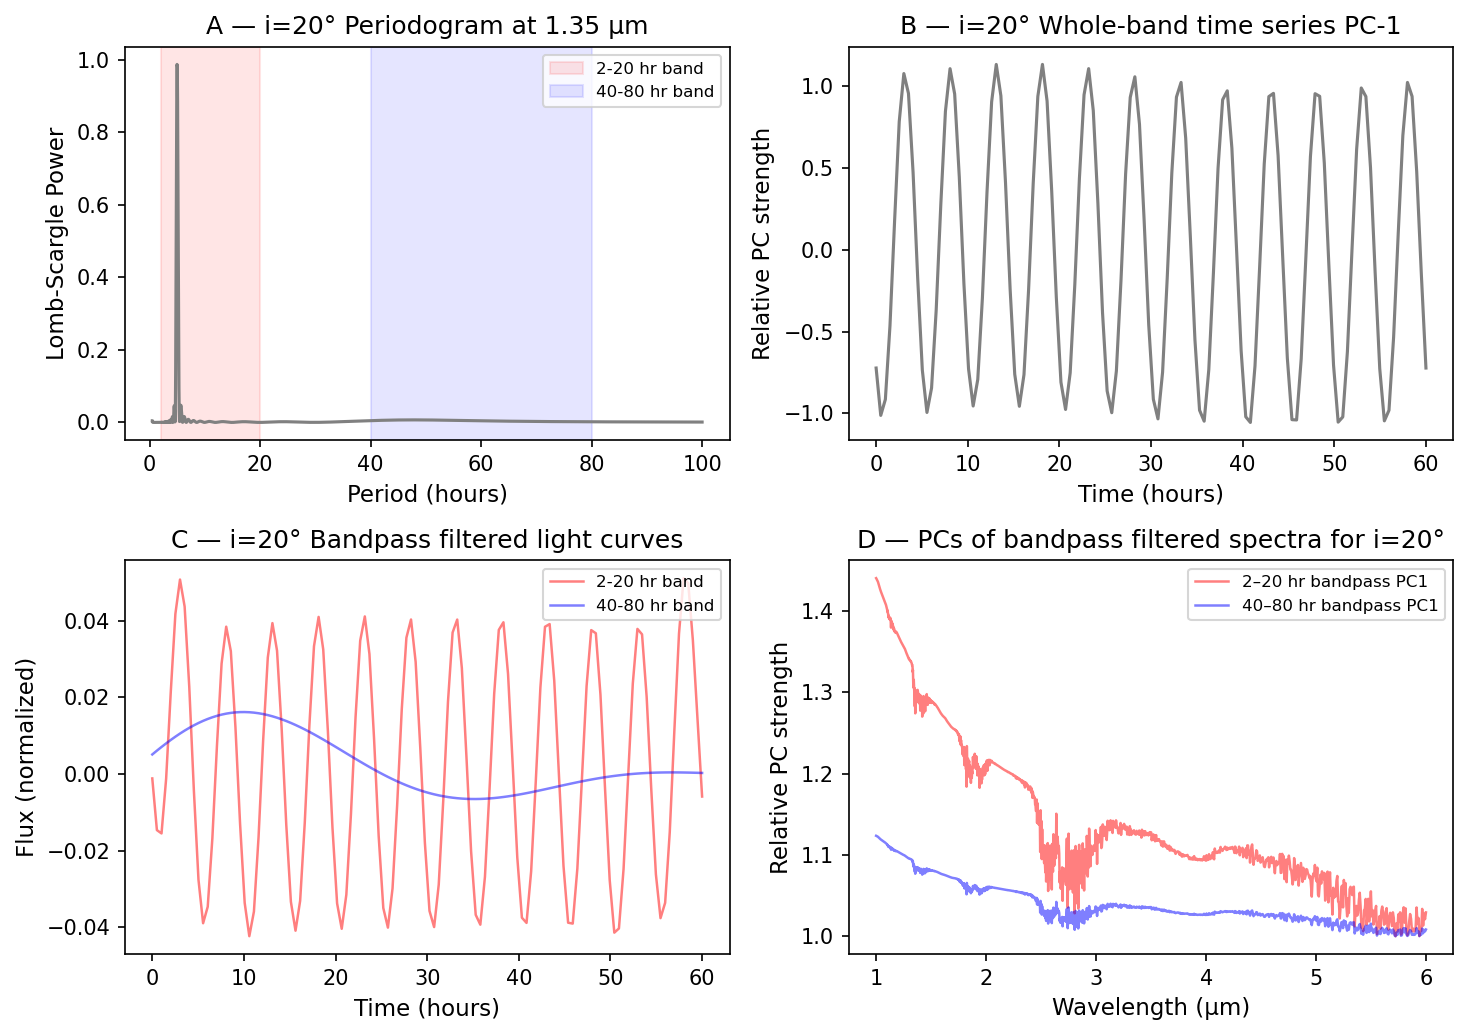

In [ ]:
### Plot periodogram analysis for static 60-hour dataset at i=20°
save = True 
# save = False

fig, axs = plt.subplots(2, 2 , figsize=(10, 7), dpi=150)

# --- Panel A: Periodograms ---
ax = axs[0, 0]
# plot periodogram of 1.35um light curve
idx_1 = np.argmin(np.abs(wave - 1.35))
lc_1 = flux_normalized_i20[:, idx_1] - 1.0
ls_1 = LombScargle(time_ts, lc_1)
power_1 = ls_1.power(freqs)
ax.plot(periods, power_1, color="gray", lw=1.5)
ax.set_xlabel("Period (hours)", fontsize=11)
ax.set_ylabel("Lomb-Scargle Power", fontsize=11)
ax.set_title("A — i=20° Periodogram at 1.35 µm", fontsize=12)

# draw box around 3-8 hr and 20-100 hr regions
ax.axvspan(band1_low, band1_high, color='r', alpha=0.1, label=f"{band1_low}-{band1_high} hr band")
ax.axvspan(band2_low, band2_high, color='b', alpha=0.1, label=f"{band2_low}-{band2_high} hr band")
ax.legend(fontsize=8)

# --- Panel B: First PCA component over time
ax = axs[0, 1]
pc1_time = X_pca_i20[:, 0]
ax.plot(time_ts, pc1_time, color="gray", lw=1.5)
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Relative PC strength", fontsize=11)
ax.set_title("B — i=20° Whole-band time series PC-1", fontsize=12)
# --- Panel C: Bandpass filtered light curves over two bands
ax = axs[1, 0]

lc_5h_1 = filtered_5h[:, idx_1]
lc_60h_1 = filtered_60h[:, idx_1]
ax.plot(time_ts, lc_5h_1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}-{band1_high} hr band")
ax.plot(time_ts, lc_60h_1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}-{band2_high} hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux (normalized)", fontsize=11)
ax.set_title("C — i=20° Bandpass filtered light curves", fontsize=12)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()

# --- Panel D: PCA over wavelengths of bandpass filtered data ---
ax = axs[1, 1]
# use the first PCA component from each bandpass filtered data
score_60h_pc1 = scores_60h[:, 0]
score_5h_pc1 = scores_5h[:, 0]

# flip y axis of 5h score and move minimum to 0
score_5h_pc1 = 1+ score_5h_pc1 - np.min(score_5h_pc1) 
# move minimum of 60h score to 0
score_60h_pc1 = 1+ score_60h_pc1 - np.min(score_60h_pc1)

ax.plot(wave, score_5h_pc1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}–{band1_high} hr bandpass PC1")
ax.plot(wave, score_60h_pc1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}–{band2_high} hr bandpass PC1")
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("Relative PC strength", fontsize=11)
ax.set_title("D — PCs of bandpass filtered spectra for i=20°", fontsize=12)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
if save:
    handle = f'PCA_i=20_bandpass_filter.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)

### 2C. Bandpass periodogram PCA for i=90

In [58]:
### Do similar periodogram analysis for dynamic 60-hour dataset at i=90°

incl_key = '90'
specs_ts_df[incl_key]  = specs_ts_df[incl_key] 
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux_i20 = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum_i20 = np.median(flux_i20, axis=0)
flux_normalized_i20 = flux_i20 / median_spectrum_i20[np.newaxis, :]

# PCA
pca_i20 = PCA(n_components=3)
pca_i20.fit(flux_normalized_i20)
X_pca_i20 = pca_i20.transform(flux_normalized_i20)

### Do periodogram analysis for static 60-hour dataset at i=90° 
periods = np.linspace(0.5, 100, 2000)      # hours
freqs   = 1.0 / periods                    # cycles / hour

n_frames, n_wave = flux_i20.shape
powers_i20 = np.zeros((n_wave, len(periods)))  # (1255, 2000)

for i in range(n_wave):
    lc = flux_normalized_i20[:, i] - 1.0       # subtract baseline
    ls = LombScargle(time_ts, lc)
    powers_i20[i, :] = ls.power(freqs)

# regular PCA on the periodogram powers
pca_pg = PCA(n_components=5)
pg_scores = pca_pg.fit_transform(powers_i20)     # (1255, 5)
# ─── BANDPASS FILTER + PCA (fallback if periodogram PCA is degenerate) ────
dt   = time_ts[1] - time_ts[0]              # 0.5 hr
fs   = 1.0 / dt                             # 2 cycles/hr (sampling freq)
nyq  = fs / 2.0                             # 1 cycle/hr

def bandpass(data_1d, lo_period, hi_period, fs, nyq, order=2):
    """Butter bandpass on a single light curve. lo/hi are in hours (period)."""
    lo_freq = 1.0 / hi_period   # lower freq edge
    hi_freq = 1.0 / lo_period   # upper freq edge
    b, a = butter(order, [lo_freq / nyq, hi_freq / nyq], btype='band')
    return filtfilt(b, a, data_1d)

# 5-hr mode: keep periods 3–8 hr  (centred on 5 hr)
# 60-hr mode: keep periods 20–100 hr  (centred on 60 hr, upper = Nyquist-ish)
filtered_5h  = np.zeros_like(flux_normalized_i20)            # (120, 1255)
filtered_60h = np.zeros_like(flux_normalized_i20)            # (120, 1255)

band1_low, band1_high = 2, 20       # hours
band2_low, band2_high = 40, 80     # hours

for i in range(n_wave):
    lc = flux_normalized_i20[:, i] - 1.0
    filtered_5h[:, i]  = bandpass(lc,  band1_low,  band1_high,  fs, nyq)
    filtered_60h[:, i] = bandpass(lc, band2_low, band2_high,  fs, nyq)

# PCA on each filtered cube  (rows = frames, cols = wave → transpose for "spectral PCA")
# We want to find the *spectral shape* of each mode, so we PCA across wavelength.
# Transpose: (1255 wave × 120 frames) so each row is a wavelength's filtered LC.
pca_5h  = PCA(n_components=3)
scores_5h  = pca_5h.fit_transform(filtered_5h.T)   # (1255, 3)

pca_60h = PCA(n_components=3)
scores_60h = pca_60h.fit_transform(filtered_60h.T) # (1255, 3)


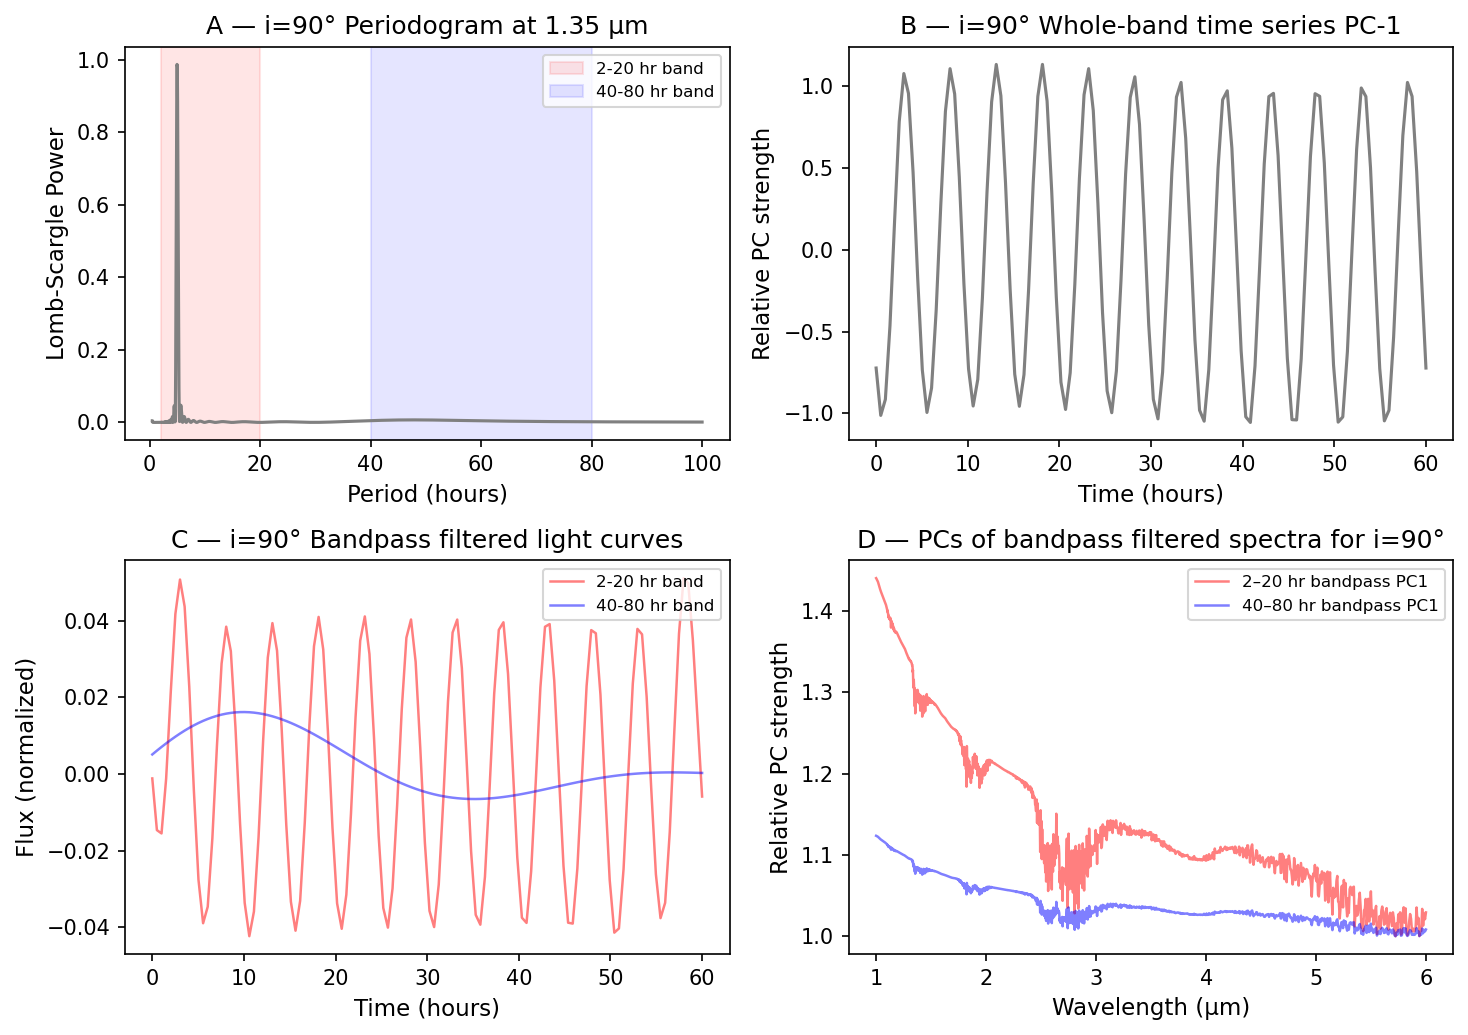

In [ ]:
### Plot periodogram analysis for static 60-hour dataset at i=90°
save = True 
# save = False

fig, axs = plt.subplots(2, 2 , figsize=(10, 7), dpi=150)

# --- Panel A: Periodograms ---
ax = axs[0, 0]
# plot periodogram of 1.35um light curve
idx_1 = np.argmin(np.abs(wave - 1.35))
lc_1 = flux_normalized_i20[:, idx_1] - 1.0
ls_1 = LombScargle(time_ts, lc_1)
power_1 = ls_1.power(freqs)
ax.plot(periods, power_1, color="gray", lw=1.5)
ax.set_xlabel("Period (hours)", fontsize=11)
ax.set_ylabel("Lomb-Scargle Power", fontsize=11)
ax.set_title("A — i=90° Periodogram at 1.35 µm", fontsize=12)

# draw box around 3-8 hr and 20-100 hr regions
ax.axvspan(band1_low, band1_high, color='r', alpha=0.1, label=f"{band1_low}-{band1_high} hr band")
ax.axvspan(band2_low, band2_high, color='b', alpha=0.1, label=f"{band2_low}-{band2_high} hr band")
ax.legend(fontsize=8)

# --- Panel B: First PCA component over time
ax = axs[0, 1]
pc1_time = X_pca_i20[:, 0]
ax.plot(time_ts, pc1_time, color="gray", lw=1.5)
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Relative PC strength", fontsize=11)
ax.set_title("B — i=90° Whole-band time series PC-1", fontsize=12)
# --- Panel C: Bandpass filtered light curves over two bands
ax = axs[1, 0]

lc_5h_1 = filtered_5h[:, idx_1]
lc_60h_1 = filtered_60h[:, idx_1]
ax.plot(time_ts, lc_5h_1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}-{band1_high} hr band")
ax.plot(time_ts, lc_60h_1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}-{band2_high} hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux (normalized)", fontsize=11)
ax.set_title("C — i=90° Bandpass filtered light curves", fontsize=12)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()

# --- Panel D: PCA over wavelengths of bandpass filtered data ---
ax = axs[1, 1]
# use the first PCA component from each bandpass filtered data
score_60h_pc1 = scores_60h[:, 0]
score_5h_pc1 = scores_5h[:, 0]

# flip y axis of 5h score and move minimum to 0
score_5h_pc1 = 1+ score_5h_pc1 - np.min(score_5h_pc1) 
# move minimum of 60h score to 0
score_60h_pc1 = 1+ score_60h_pc1 - np.min(score_60h_pc1)

ax.plot(wave, score_5h_pc1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}–{band1_high} hr bandpass PC1")
ax.plot(wave, score_60h_pc1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}–{band2_high} hr bandpass PC1")
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("Relative PC strength", fontsize=11)
ax.set_title("D — PCs of bandpass filtered spectra for i=90°", fontsize=12)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
if save:
    handle = f'PCA_i=90_bandpass_filter.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)

### (optional) Investigative plotting of periodograms along with bandpass filtered PCAs

In [ ]:
# ─── 5. PLOTTING ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
gs  = GridSpec(4, 2, figure=fig, hspace=0.35, wspace=0.3)

# --- Panel A: example periodograms at 3 wavelengths ---
ax = fig.add_subplot(gs[0, :])
test_waves = [1.35, 2.45, 4.9]   # µm — match user's stated bins
colors = ["#e74c3c", "#3498db", "#2ecc71"]
for wt, col in zip(test_waves, colors):
    idx = np.argmin(np.abs(wave - wt))
    ax.plot(periods, powers[idx, :], color=col, label=f"{wave[idx]:.2f} µm", lw=1.2)
ax.set_xlabel("Period (hours)", fontsize=12)
ax.set_ylabel("Lomb-Scargle Power", fontsize=12)
ax.set_title("A — Periodograms at representative wavelengths", fontsize=13)
ax.axvline(5, color="k", ls="--", lw=0.8, alpha=0.5)
ax.axvline(60, color="k", ls="--", lw=0.8, alpha=0.5)
ax.text(5.5, ax.get_ylim()[1]*0.9, "5 hr", fontsize=10)
ax.text(61, ax.get_ylim()[1]*0.9, "60 hr", fontsize=10)
ax.legend(fontsize=10)
ax.set_xlim(0, 100)

# --- Panel B: PCA scores from periodogram (spectral color of each PC) ---
ax = fig.add_subplot(gs[1, 0])
for k in range(3):
    ax.plot(wave, pg_scores[:, k], label=f"PC{k+1} ({pca_pg.explained_variance_ratio_[k]*100:.2f}%)", lw=1)
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("PC Score", fontsize=11)
ax.set_title("B — Periodogram PCA: spectral loading", fontsize=12)
ax.legend(fontsize=9)

# --- Panel C: PCA components (period-space) ---
ax = fig.add_subplot(gs[1, 1])
for k in range(3):
    ax.plot(periods, pca_pg.components_[k, :], label=f"PC{k+1}", lw=1)
ax.set_xlabel("Period (hours)", fontsize=11)
ax.set_ylabel("Component weight", fontsize=11)
ax.set_title("C — Periodogram PCA: period-space components", fontsize=12)
ax.axvline(5, color="k", ls="--", lw=0.8, alpha=0.4)
ax.axvline(60, color="k", ls="--", lw=0.8, alpha=0.4)
ax.set_xlim(0, 100)
ax.legend(fontsize=9)

# --- Panel D: Bandpass-filtered light curves (one example wavelength) ---
ax = fig.add_subplot(gs[2, 0])
idx_ex = np.argmin(np.abs(wave - 1.35))
ax.plot(time_ts, flux_normalized[:, idx_ex] - 1, color="gray",  lw=0.8, alpha=0.6, label="Full residual")
ax.plot(time_ts, filtered_5h[:, idx_ex],  color="#e74c3c", lw=1.2, label="3–8 hr band")
ax.plot(time_ts, filtered_60h[:, idx_ex], color="#3498db", lw=1.2, label="20–100 hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Residual flux", fontsize=11)
ax.set_title(f"D — Filtered LCs at {wave[idx_ex]:.2f} µm", fontsize=12)
ax.legend(fontsize=9)

# --- Panel E: 5-hr PCA spectral scores ---
ax = fig.add_subplot(gs[2, 1])
for k in range(3):
    ax.plot(wave, scores_5h[:, k], label=f"PC{k+1} ({pca_5h.explained_variance_ratio_[k]*100:.1f}%)", lw=1)
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("PC Score", fontsize=11)
ax.set_title("E — 5-hr band PCA: spectral shape", fontsize=12)
ax.legend(fontsize=9)

# --- Panel F: 60-hr PCA spectral scores ---
ax = fig.add_subplot(gs[3, 0])
for k in range(3):
    ax.plot(wave, scores_60h[:, k], label=f"PC{k+1} ({pca_60h.explained_variance_ratio_[k]*100:.1f}%)", lw=1)
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("PC Score", fontsize=11)
ax.set_title("F — 60-hr band PCA: spectral shape", fontsize=12)
ax.legend(fontsize=9)

# --- Panel G: Reconstructed time series from bandpass PCs ---
ax = fig.add_subplot(gs[3, 1])
# PCA was fit on (1255 wave × 120 frames), so components[k] IS the k-th time series
recon_5h_pc1  = pca_5h.components_[0, :]    # (120,)
recon_60h_pc1 = pca_60h.components_[0, :]   # (120,)
recon_5h_pc1  /= np.std(recon_5h_pc1)
recon_60h_pc1 /= np.std(recon_60h_pc1)
ax.plot(time_ts, recon_5h_pc1,  color="#e74c3c", lw=1.2, label="5-hr band PC1")
ax.plot(time_ts, recon_60h_pc1, color="#3498db", lw=1.2, label="60-hr band PC1")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Normalised PC1 projection", fontsize=11)
ax.set_title("G — PC1 time series (bandpass separated)", fontsize=12)
ax.legend(fontsize=9)
